# CH 4 - 9 : THE EQUIVALENCE OF FREQUENCY AND AREA

## Objectif du notebook

Ce cahier explique une idée fondamentale en statistique appliquée au trading :

> **Dans une distribution de fréquence relative, l’aire représente une probabilité.**

Autrement dit, un histogramme n’est pas seulement un dessin.  
C’est un instrument de mesure du hasard.

Dans le contexte EBTA, ce concept prépare directement à la compréhension de la **p-value** :  
on mesure la surface située dans la queue de distribution pour savoir si un résultat de backtest est rare ou normal sous l’hypothèse du hasard.


## 1. L’idée intuitive

Imagine que tu lances une stratégie sur plusieurs périodes, ou que tu simules plusieurs résultats possibles par bootstrap.

Tu obtiens une liste de résultats :

- parfois faibles,
- parfois moyens,
- parfois élevés.

Tu ranges ensuite ces résultats dans un histogramme.

Chaque barre répond à une question simple :

> Combien de fois les résultats sont tombés dans cette zone ?

Mais Aronson ajoute une idée essentielle :

> La fréquence peut être transformée en aire, et cette aire peut être lue comme une probabilité.

Donc si une zone représente 20% de l’aire totale du graphique, alors elle représente 20% des observations.


## 2. Fréquence brute vs fréquence relative

Il y a deux manières de lire un histogramme.

### Fréquence brute

La hauteur d’une barre indique le **nombre d’observations**.

Exemple :

- 10 résultats dans une barre,
- 50 résultats au total.

La fréquence brute est 10.

### Fréquence relative

La hauteur ou l’aire est ramenée au total.

$$
\text{Fréquence relative} = \frac{\text{nombre dans la barre}}{\text{nombre total}}
$$

Donc :

$$
\frac{10}{50} = 0.20 = 20\%
$$

C’est là que le graphique devient un outil de probabilité.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Exemple simple inspiré du livre
# Chaque valeur représente une zone de résultat possible
resultats = np.array([
    0.40, 0.45, 0.50, 0.55, 0.60,
    0.60, 0.60, 0.60, 0.60,
    0.65, 0.65, 0.65, 0.65, 0.65,
    0.70, 0.70, 0.70,
    0.75
])

n = len(resultats)
n


18

Ici, nous avons un petit échantillon de résultats possibles.

Ce n’est pas encore un backtest réaliste.  
C’est volontairement simple pour voir clairement le mécanisme.


In [2]:
# Comptage des fréquences brutes
freq_brute = pd.Series(resultats).value_counts().sort_index()

# Fréquences relatives
freq_relative = freq_brute / n

table = pd.DataFrame({
    "frequence_brute": freq_brute,
    "frequence_relative": freq_relative
})

table


,frequence_brute,frequence_relative
0.40,1,0.055556
0.45,1,0.055556
0.50,1,0.055556
0.55,1,0.055556
0.60,5,0.277778
0.65,5,0.277778
0.70,3,0.166667
0.75,1,0.055556


## 3. Lire une barre comme une part du total

La colonne `frequence_relative` indique la part du total représentée par chaque résultat.

Par exemple, si une valeur a une fréquence relative de 0.20, cela veut dire :

> 20% des observations sont tombées sur cette valeur.

En géométrie de l’histogramme, cela signifie :

> Cette barre représente 20% de l’aire totale.


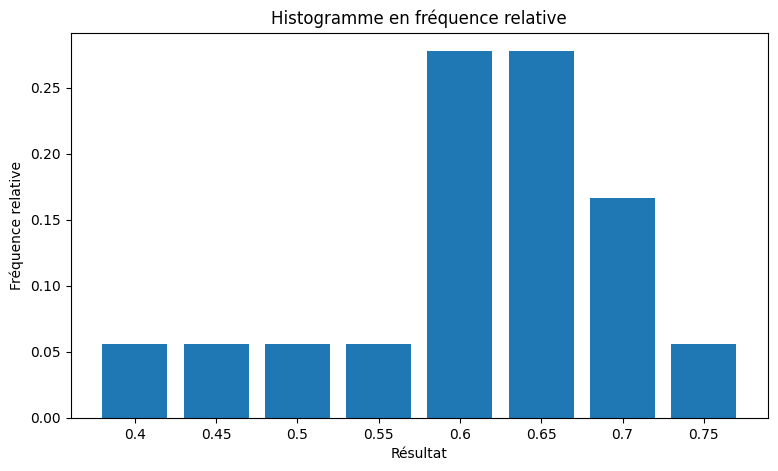

Somme des fréquences relatives : 1.0


In [3]:
plt.figure(figsize=(9, 5))
plt.bar(table.index.astype(str), table["frequence_relative"])
plt.xlabel("Résultat")
plt.ylabel("Fréquence relative")
plt.title("Histogramme en fréquence relative")
plt.show()

print("Somme des fréquences relatives :", table["frequence_relative"].sum())


## 4. Point Eureka : l’aire totale vaut 1

Dans une distribution de fréquence relative :

$$
\text{Aire totale} = 1.0
$$

Et 1.0 signifie :

$$
100\%
$$

Donc chaque barre est une petite portion de 100%.

Voilà le déclic :

> Si le graphique entier représente tous les scénarios possibles, alors une zone du graphique représente une probabilité.


## 5. Calculer une probabilité de queue

En trading statistique, on ne s’intéresse pas seulement à une barre isolée.

On veut souvent savoir :

> Quelle est la probabilité d’obtenir un résultat égal ou supérieur à un certain niveau ?

C’est une probabilité de queue droite.

Exemple :

$$
P(X \geq 0.65)
$$

Pour la calculer, on additionne les aires des barres à droite de 0.65, incluant 0.65.


In [4]:
seuil = 0.65

zone_queue = table[table.index >= seuil]
prob_queue = zone_queue["frequence_relative"].sum()

zone_queue, prob_queue


(      frequence_brute  frequence_relative
 0.65                5            0.277778
 0.70                3            0.166667
 0.75                1            0.055556,
 np.float64(0.5))

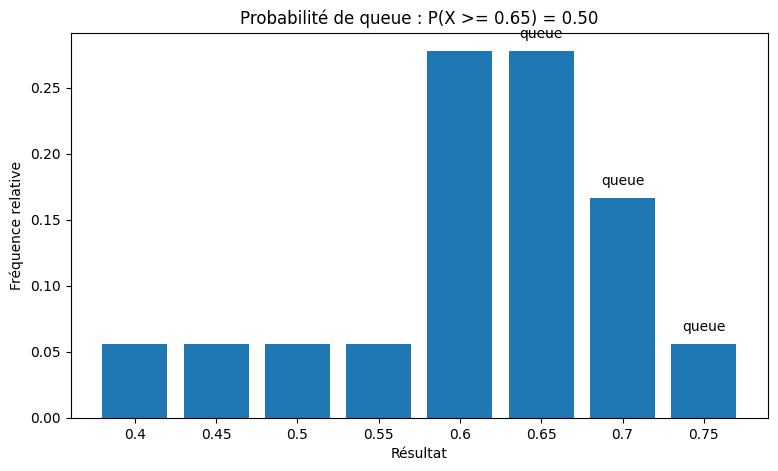

Probabilité d'obtenir un résultat >= 0.65 : 50.00%


In [5]:
plt.figure(figsize=(9, 5))

x_labels = table.index.astype(str)
heights = table["frequence_relative"]

plt.bar(x_labels, heights)

# On ajoute un petit marquage textuel au-dessus des barres de la queue
for i, (idx, val) in enumerate(zip(table.index, heights)):
    if idx >= seuil:
        plt.text(i, val + 0.01, "queue", ha="center")

plt.xlabel("Résultat")
plt.ylabel("Fréquence relative")
plt.title(f"Probabilité de queue : P(X >= {seuil}) = {prob_queue:.2f}")
plt.show()

print(f"Probabilité d'obtenir un résultat >= {seuil} : {prob_queue:.2%}")


## 6. Traduction directe en trading

Imagine maintenant que ces résultats représentent ce que le hasard peut produire.

Par exemple :

- tu prends une stratégie sans vrai edge,
- tu fais un bootstrap ou une simulation,
- tu observes les profits moyens possibles sous l’hypothèse nulle.

Si ton backtest réel donne un résultat très élevé, tu demandes :

> Quelle surface de la distribution du hasard est encore plus extrême que mon résultat ?

Cette surface est la **p-value**.

### Interprétation

Si la zone à droite de ton résultat représente 20% :

> Ton résultat n’est pas très rare sous le hasard.

Si elle représente 5% :

> Ton résultat commence à être statistiquement rare.

Si elle représente 1% :

> Ton résultat est très difficile à expliquer par le hasard seul.

C’est le passage du ressenti à la mesure.


## 7. Exemple trading/backtest simulé

Maintenant, on simule 1 000 performances de stratégies qui n’ont aucun edge réel.

Elles sont centrées autour de zéro.

Puis on place un résultat de backtest observé et on mesure l’aire de la queue droite.


In [6]:
np.random.seed(42)

# Simulation de 1000 résultats sous l'hypothèse nulle :
# moyenne proche de 0, dispersion aléatoire
resultats_hasard = np.random.normal(loc=0.0, scale=1.0, size=1000)

# Résultat observé du backtest
resultat_backtest = 1.75

# P-value empirique = proportion des résultats du hasard >= résultat observé
p_value_empirique = np.mean(resultats_hasard >= resultat_backtest)

p_value_empirique


np.float64(0.048)

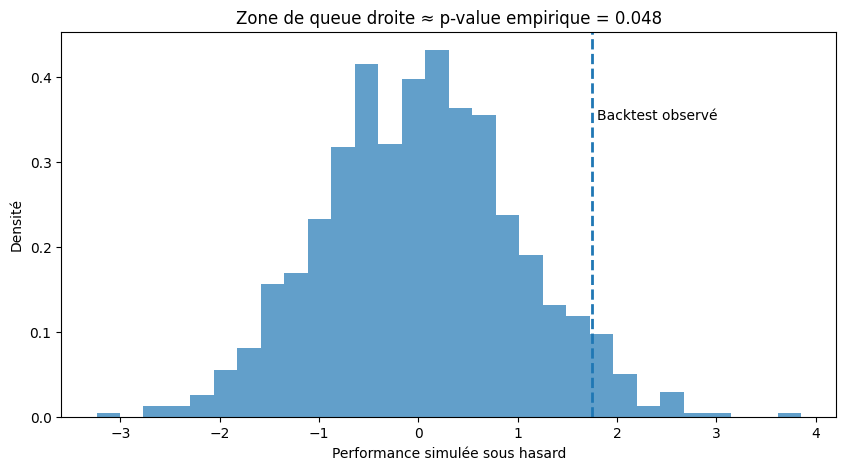

P-value empirique : 0.048
Soit environ : 4.80%


In [7]:
plt.figure(figsize=(10, 5))

# Histogramme en densité : l'aire totale sous l'histogramme vaut environ 1
plt.hist(resultats_hasard, bins=30, density=True, alpha=0.7)

plt.axvline(resultat_backtest, linestyle="--", linewidth=2)
plt.text(resultat_backtest + 0.05, 0.35, "Backtest observé")

plt.xlabel("Performance simulée sous hasard")
plt.ylabel("Densité")
plt.title(f"Zone de queue droite ≈ p-value empirique = {p_value_empirique:.3f}")
plt.show()

print(f"P-value empirique : {p_value_empirique:.3f}")
print(f"Soit environ : {p_value_empirique:.2%}")


## 8. Pourquoi `density=True` est important ?

Dans `matplotlib`, lorsque l’on écrit :

```python
plt.hist(donnees, density=True)
```

on ne demande plus seulement un comptage brut.

On demande à Python de normaliser l’histogramme pour que :

$$
\text{aire totale} \approx 1
$$

Cela permet de lire l’histogramme comme une approximation d’une distribution de probabilité.

Attention :

- la hauteur d’une barre n’est pas toujours directement la probabilité,
- surtout si les barres ont une largeur différente,
- c’est bien **l’aire** de la barre qui compte.

Dans un histogramme simple avec barres de même largeur, hauteur et aire évoluent ensemble.  
Mais le principe rigoureux reste : **probabilité = aire**.


## 9. Lien avec la p-value

La p-value répond à la question :

> Si ma stratégie n’avait aucun vrai edge, quelle serait la probabilité d’obtenir un résultat au moins aussi bon que celui observé ?

Mathématiquement :

$$
p\text{-value} = P(X \geq \text{résultat observé} \mid H_0)
$$

Dans le graphique, c’est :

> L’aire située à droite du résultat observé.

Donc la p-value n’est pas une formule magique.  
C’est simplement une surface mesurée dans la distribution du hasard.


In [8]:
# Testons plusieurs résultats observés pour voir l'effet sur la p-value
resultats_observes = [0.5, 1.0, 1.5, 2.0, 2.5]

comparaison = pd.DataFrame({
    "resultat_observe": resultats_observes,
    "p_value_empirique": [np.mean(resultats_hasard >= x) for x in resultats_observes]
})

comparaison["interpretation"] = pd.cut(
    comparaison["p_value_empirique"],
    bins=[-0.01, 0.01, 0.05, 0.10, 1.0],
    labels=[
        "très rare sous H0",
        "rare sous H0",
        "modérément rare",
        "pas rare"
    ]
)

comparaison


,resultat_observe,p_value_empirique,interpretation
0,0.5,0.306,pas rare
1,1.0,0.155,pas rare
2,1.5,0.075,modérément rare
3,2.0,0.024,rare sous H0
4,2.5,0.007,très rare sous H0


## 10. Mini-exercice EBTA

Lis le tableau précédent comme un trader objectif :

- plus le résultat observé est élevé,
- plus il est loin dans la queue droite,
- plus l’aire restante à droite diminue,
- plus la p-value baisse.

Le raisonnement devient :

> Mon résultat est-il vraiment exceptionnel, ou est-il simplement une performance que le hasard produit souvent ?

C’est exactement la discipline mentale EBTA :

ne pas croire le backtest parce qu’il est beau,  
mais mesurer à quel point il est rare sous l’hypothèse du hasard.


## 11. Résumé ultra-simple

À retenir absolument :

1. Un histogramme de fréquence relative représente 100% des observations.
2. L’aire totale vaut 1.
3. Une barre représente une fraction de cette aire.
4. Une zone composée de plusieurs barres représente une probabilité cumulée.
5. La queue droite permet de calculer la probabilité d’obtenir un résultat au moins aussi élevé.
6. Cette logique est la base visuelle de la p-value.
7. En trading, cela permet de transformer :  
   “ce backtest a l’air impressionnant”  
   en :  
   “ce backtest a seulement X% de chances d’être produit par le hasard”.


## 12. Phrase Eureka

> La fréquence te dit combien de fois une chose arrive.  
> L’aire te permet de transformer ce comptage en probabilité.  
> Et la probabilité te permet de juger si ton backtest est banal ou exceptionnel.

C’est le pont entre le graphique et l’inférence statistique.
